# JamUNet model trained with the spatial dataset - testing and visualisation

This notebook was used for testing the model, computing the metric scores, and visualising the predictions.

In [1]:
%cd ..

f:\TUD_CEG_Repository\DSAIE\jamunet-morpho-braided-main


In [2]:
# reload modules to avoid restarting the notebook every time these are updated

%load_ext autoreload
%autoreload 2

In [3]:
# import modules 

import torch 
import copy
import time

from torch.utils.data import DataLoader

from model.train_eval import * 
from preprocessing.dataset_generation import create_full_dataset

from postprocessing.metrics import *
from postprocessing.plot_results import *
from postprocessing.save_results import load_model

# Enable interactive widgets in Jupyter Notebook
%matplotlib inline
%matplotlib widget

In [4]:
# set the device where operations are performed
# if only one GPU is present you might need to remove the index "0" 
# torch.device('cuda:0') --> torch.device('cuda') / torch.cuda.get_device_name(0) --> torch.cuda.get_device_name() 

if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print("CUDA Device Count: ", torch.cuda.device_count())
    print("CUDA Device Name: ", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    
print(f'Using device: {device}')

CUDA Device Count:  1
CUDA Device Name:  NVIDIA GeForce RTX 3060 Laptop GPU
Using device: cuda:0


In [5]:
# set common keys required for functions

train = 'training'
val = 'validation'
test = 'testing'

In [6]:
# load all datasets

# by default March images are used - if another month is used change the number (available months: 1-4)
dataset_path = r'data\satellite\dataset_month3' 

dtype=torch.float32

val_set = create_full_dataset(val, dir_folders=dataset_path, device=device, dtype=dtype)
test_set = create_full_dataset(test, dir_folders=dataset_path, device=device, dtype=dtype)

c:\Users\adrie\anaconda3\envs\braided-gpu\Lib\site-packages\osgeo\gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


**<span style="color:red">Attention!</span> Always remember to load the correct <code>save_path</code> file before running the following cells, in order to match all keys successfully when loading the model.**

In [ ]:
# load model with min val loss

save_path_loss = rf'models_trained\UNet3D_spatial_bloss_month3_4dwns_8ihiddim_3ker_maxpool_0.05ilr_15step_0.75gamma_16batch_100epochs_0.5wthr.pth'

In [ ]:
# load model with max recall

save_path_recall = rf'model\losses_metrics\00_Original\UNet3D_brecall_spatial_month3_4dwns_8ihiddim_3ker_maxpool_0.05ilr_15step_0.75gamma_16batch_100epochs_0.5wthr.pth'

In [9]:
# load JamUNet architecture

from model.st_unet.st_unet import *

n_channels = test_set[0][0].shape[0]
n_classes = 1
init_hid_dim = 8
kernel_size = 3
pooling = 'max'

model_loss = UNet3D(n_channels=n_channels, n_classes=n_classes, init_hid_dim=init_hid_dim, 
                         kernel_size=kernel_size, pooling=pooling, bilinear=False, drop_channels=False).to(device)

In [10]:
# deepcopy the model to avoid overwriting

model_recall = copy.deepcopy(model_loss)

In [11]:
loss_f = 'BCE'
batch_size = 16

# dataloaders to input data to the model in batches -- see note above

val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

In [12]:
# load model with min val loss

load_model(model_loss, save_path_loss, device=device)

<All keys matched successfully>

In [13]:
sample = 15

input_img = test_set[sample][0].unsqueeze(0).to(device)
target_img = test_set[sample][1].to(device)

prediction = model_loss(input_img).detach().to(device)
# check that the predictions from the same sample are different from those of the max recall model
print(prediction) 

tensor([[[[0.0229, 0.0086, 0.0102,  ..., 0.0111, 0.0100, 0.0447],
          [0.0044, 0.0010, 0.0015,  ..., 0.0017, 0.0013, 0.0088],
          [0.0050, 0.0012, 0.0020,  ..., 0.0022, 0.0017, 0.0102],
          ...,
          [0.0031, 0.0006, 0.0007,  ..., 0.0015, 0.0011, 0.0080],
          [0.0036, 0.0006, 0.0008,  ..., 0.0015, 0.0012, 0.0085],
          [0.0110, 0.0036, 0.0041,  ..., 0.0063, 0.0052, 0.0215]]]],
       device='cuda:0')


In [14]:
# load model with max recall

load_model(model_recall, save_path_recall, device=device)

<All keys matched successfully>

In [15]:
sample = 15

input_img = test_set[sample][0].unsqueeze(0).to(device)
target_img = test_set[sample][1].to(device)

prediction = model_recall(input_img).detach().to(device)
# check that the predictions from the same sample are different from those of the min loss model
print(prediction)

tensor([[[[0.0260, 0.0046, 0.0055,  ..., 0.0062, 0.0058, 0.0240],
          [0.0045, 0.0003, 0.0004,  ..., 0.0006, 0.0005, 0.0053],
          [0.0050, 0.0004, 0.0006,  ..., 0.0008, 0.0006, 0.0053],
          ...,
          [0.0038, 0.0003, 0.0003,  ..., 0.0005, 0.0004, 0.0046],
          [0.0039, 0.0003, 0.0003,  ..., 0.0004, 0.0003, 0.0038],
          [0.0229, 0.0034, 0.0034,  ..., 0.0041, 0.0038, 0.0204]]]],
       device='cuda:0')


In [ ]:
# load losses and metrics saved during training and validation for plotting

losses_metrics = load_losses_metrics(r'model\losses_metrics\00_Original\UNet3D_spatial_losses&metrics_month3_4dwns_8ihiddim_3ker_maxpool_0.05ilr_15step_0.75gamma_16batch_100epochs_0.5wthr.csv')
train_losses, val_losses = losses_metrics['Training loss'], losses_metrics['Validation loss']
metrics = [losses_metrics[losses_metrics.columns[i]].tolist() for i in range(2, len(losses_metrics.columns))]

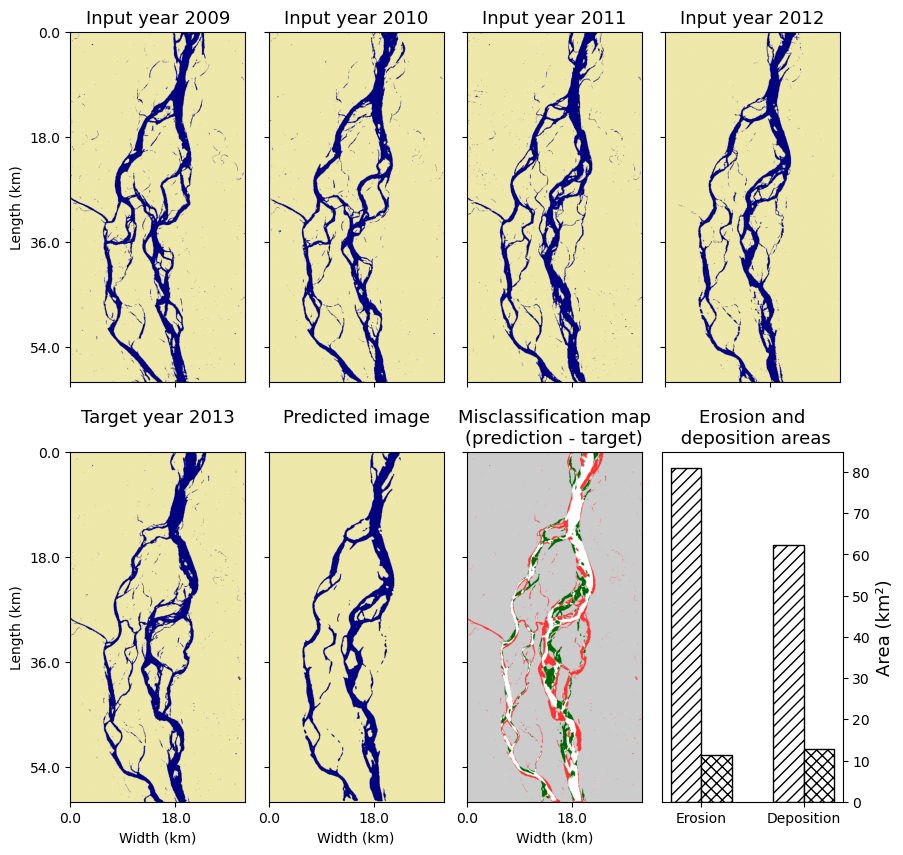

In [17]:
# max recall model predictions

%matplotlib inline
show_evolution_nolegend(11, test_set, model_recall, loss_recall='max recall', device=device, save_img=False)

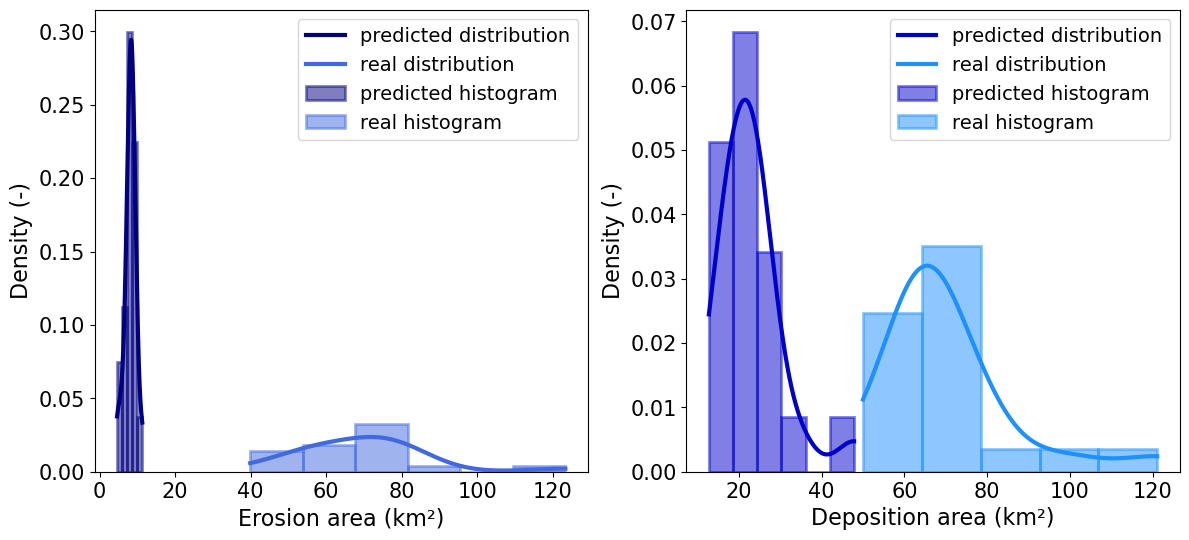

In [18]:
%matplotlib inline
erosion_deposition_distribution(model_recall, test_set, model_type='max_recall', device=device, save_img=False)